In [1]:
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import os
import tensorflow as tf
tf.random.set_seed(0)

In [2]:
import os
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [4]:
print("Contents of downloaded dataset root:")
for item in os.listdir(path):
    print(item)

Contents of downloaded dataset root:
PlantVillage
plantvillage


In [5]:
import os

DATA_DIR = os.path.join(path, 'plantvillage', 'PlantVillage')
print(f"Updated DATA_DIR: {DATA_DIR}")

print("Contents of DATA_DIR:")
for item in os.listdir(DATA_DIR):
    print(item)

Updated DATA_DIR: /kaggle/input/plantdisease/plantvillage/PlantVillage
Contents of DATA_DIR:
Pepper__bell___Bacterial_spot
Potato___healthy
Tomato_Leaf_Mold
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Tomato_Septoria_leaf_spot
Tomato_healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___healthy
Potato___Late_blight
Tomato_Late_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus


In [6]:
print(os.listdir(DATA_DIR))

['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [7]:
print(len(os.listdir(DATA_DIR)))

15


In [8]:
img_size=224
batch_size=32

In [9]:
data_gen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
    )


In [10]:
train_generator=data_gen.flow_from_directory(
    DATA_DIR,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 16516 images belonging to 15 classes.


In [11]:
validation_generator=data_gen.flow_from_directory(
    DATA_DIR,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 4122 images belonging to 15 classes.


In [12]:
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_size,img_size,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(15,activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,964,367 (45.64 MB)

 Trainable params: 11,964,367 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
from IPython.core import history
history=model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 177s 331ms/step - accuracy: 0.6213 - loss: 1.2479 - val_accuracy: 0.7808 - val_loss: 0.6736
Epoch 2/5
  1/516 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.7812 - loss: 0.7782

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


516/516 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7812 - loss: 0.7782 - val_accuracy: 0.7593 - val_loss: 0.7334
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 45s 88ms/step - accuracy: 0.8288 - loss: 0.5159 - val_accuracy: 0.8181 - val_loss: 0.5448
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.8438 - loss: 0.4186 - val_accuracy: 0.8157 - val_loss: 0.5516
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 45s 87ms/step - accuracy: 0.9135 - loss: 0.2589 - val_accuracy: 0.8298 - val_loss: 0.5325


In [16]:
print("Evaluating model...")
val_loss, val_accuracy=model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation accuracy: {val_accuracy*100:.2f}%")

Evaluating model...
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.8298 - loss: 0.5340
Validation accuracy: 82.98%


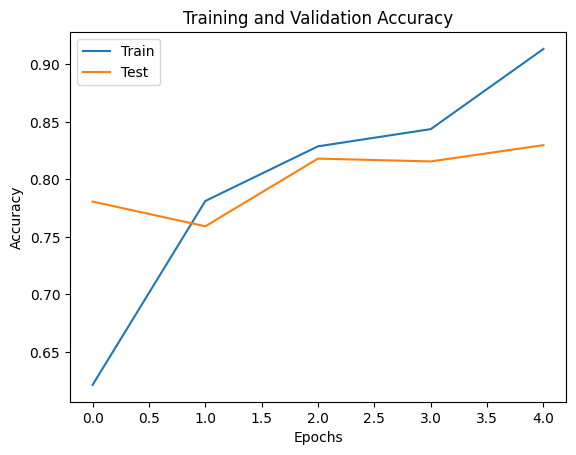

In [17]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train','Test'], loc='upper left')
plt.title('Training and Validation Accuracy')
plt.show()


In [18]:
def load_and_preprocess_image(image_path):
    img=Image.open(image_path)
    img=img.resize((img_size,img_size))
    img_array=np.array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array=img_array.astype('float32')/255.0
    return img_array
def predict_disease(model, image_path, class_indices):
    preprocessed_img=load_and_preprocess_image(image_path)
    prediction=model.predict(preprocessed_img)
    predicted_class_index=np.argmax(prediction,axis=1)[0]
    predicted_class=class_indices[predicted_class_index]
    return predicted_class

In [19]:
class_indices={v: k for k, v in train_generator.class_indices.items()}
class_indices

{0: 'Pepper__bell___Bacterial_spot',
 1: 'Pepper__bell___healthy',
 2: 'Potato___Early_blight',
 3: 'Potato___Late_blight',
 4: 'Potato___healthy',
 5: 'Tomato_Bacterial_spot',
 6: 'Tomato_Early_blight',
 7: 'Tomato_Late_blight',
 8: 'Tomato_Leaf_Mold',
 9: 'Tomato_Septoria_leaf_spot',
 10: 'Tomato_Spider_mites_Two_spotted_spider_mite',
 11: 'Tomato__Target_Spot',
 12: 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 13: 'Tomato__Tomato_mosaic_virus',
 14: 'Tomato_healthy'}

In [20]:
json.dump(class_indices, open('class_indices.json', 'w'))

In [21]:
model.save('plant_disease_model.h5', include_optimizer=False)

import os
size_mb = os.path.getsize('plant_disease_model.h5') / (1024 * 1024)
print(f"Model saved successfully! File size: {size_mb:.2f} MB (Directly pushable to GitHub)")

Model saved successfully! File size: 45.67 MB (Directly pushable to GitHub)


In [22]:
try:
    from google.colab import files
    files.download('plant_disease_model.h5')
    files.download('class_indices.json')
except ImportError:
    print('Files saved in current directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>